100%|██████████| 12000/12000 [00:01<00:00, 6398.03it/s]


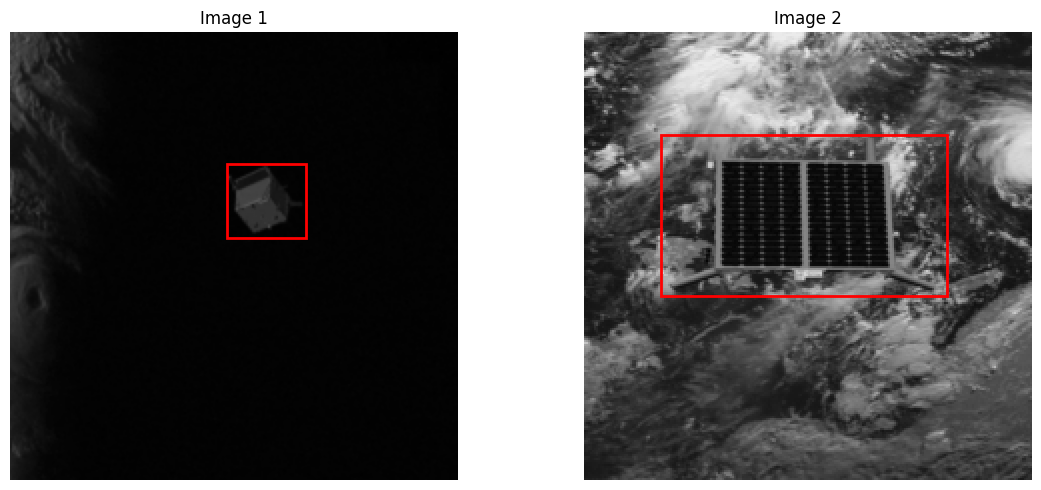

/tmp/ipykernel_19/1132231232.py:545: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Layer (type:depth-idx)                             Output Shape              Param #
SPN                                                --                        --
├─GeneralizedRCNNTransform: 1-1                    [1, 3, 224, 224]          --
├─Conv2d: 1-2                                      [1, 96, 54, 54]           34,944
├─MaxPool2d: 1-3                                   [1, 96, 26, 26]           --
├─LocalResponseNorm: 1-4                           [1, 96, 26, 26]           --
├─Conv2d: 1-5                                      [1, 256, 26, 26]          307,456
├─MaxPool2d: 1-6                                   [1, 256, 12, 12]          --
├─LocalResponseNorm: 1-7                           [1, 256, 12, 12]          --
├─Conv2d: 1-8                                      [1, 384, 12, 12]          885,120
├─Conv2d: 1-9                                      [1, 384, 12, 12]          663,936
├─Conv2d: 1-10                                     [1, 256, 12, 12]          442,624
├─MaxPool2d

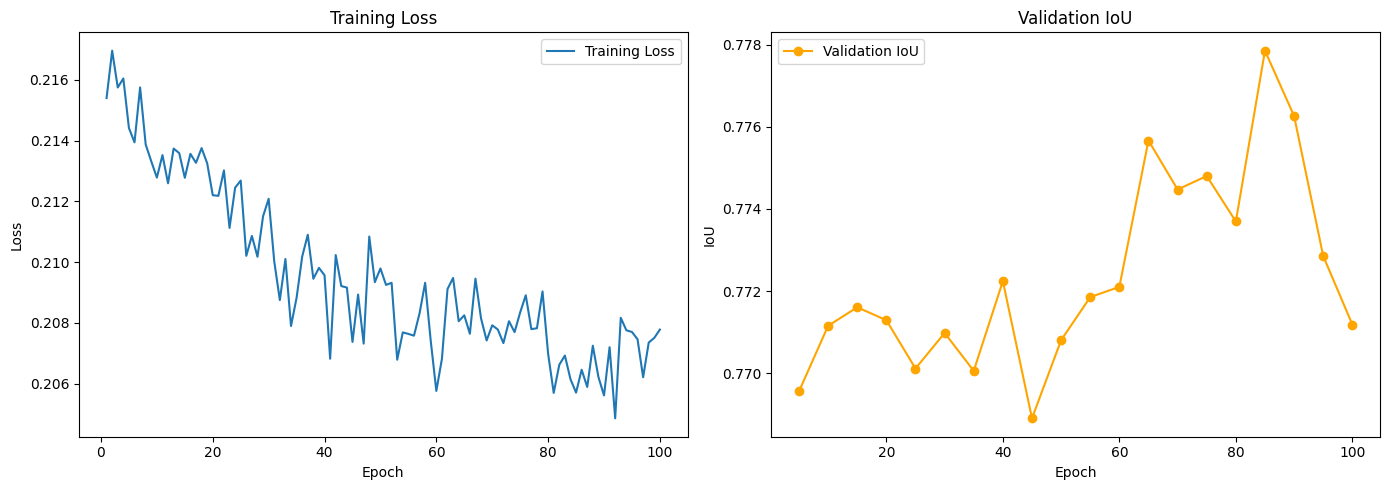

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models, ops
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RegionProposalNetwork, RPNHead
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection.faster_rcnn import TwoMLPHead, FastRCNNPredictor
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchinfo import summary
from scipy.io import loadmat
from scipy.spatial.transform import Rotation as R
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import math

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class Speed(Dataset):
    def __init__(self, images_dir, json_dir, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform

        self.num_classes = 1000
        self.num_neighbors = 5

        self.imagesList = []
        self.BBoxList = []
        self.keypointsList = []  #

        cnt=0

        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }


            for filename in tqdm.tqdm(os.listdir(self.images_dir)):
                if filename not in lookup:
                    continue
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypts3d) # (2, 11)
                
                # Store the 2D keypoints for this image
                self.keypointsList.append(torch.tensor(keypts2d, dtype=torch.float32))
                
                xmin = np.min(keypts2d[0])
                xmax = np.max(keypts2d[0])
                ymin = np.min(keypts2d[1])
                ymax = np.max(keypts2d[1])


                width = xmax - xmin
                height = ymax - ymin
                margin_x = width * 0.05
                margin_y = height * 0.05

                xmin = max(0, xmin - margin_x)
                xmax = xmax + margin_x
                ymin = max(0, ymin - margin_y)
                ymax = ymax + margin_y

                BBox = [xmin, xmax, ymin, ymax]

                self.BBoxList.append(torch.tensor(BBox, dtype=torch.float32))

                cnt=cnt+1
                # if cnt>50:
                #     break

    def __len__(self):
        return len(self.imagesList)

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        image = Image.open(image_path).convert('RGB')
        orig_w, orig_h = image.size
        BBox = self.BBoxList[idx]
        keypoints = self.keypointsList[idx].clone()  

        new_w, new_h = orig_w, orig_h

        if self.transform:
            resize_transform = transforms.Resize((224, 224))
            image = resize_transform(image)
            new_w, new_h = 224, 224
            
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h
            
            keypoints[0, :] *= scale_x 
            keypoints[1, :] *= scale_y  
            
            xmin, xmax, ymin, ymax = BBox.tolist()
            xmin *= scale_x
            xmax *= scale_x
            ymin *= scale_y
            ymax *= scale_y
            BBox = torch.tensor([xmin, xmax, ymin, ymax], dtype=BBox.dtype, device=BBox.device)
        
        if torch.rand(1) > 0.4:
            image = transforms.functional.hflip(image)
            keypoints[0, :] = new_w - keypoints[0, :]
            xmin, xmax, ymin, ymax = BBox.tolist()
            new_xmin = new_w - xmax
            new_xmax = new_w - xmin
            BBox = torch.tensor([new_xmin, new_xmax, ymin, ymax], dtype=BBox.dtype, device=BBox.device)

        
        if torch.rand(1) > 0.4:
            angles = [0, 90, 180, 270]
            angle = angles[torch.randint(0, len(angles), (1,)).item()]
            
            if angle != 0:  
                image = transforms.functional.rotate(image, -angle)  
                keypoints_rotated = torch.zeros_like(keypoints)
                
                if angle == 90:
                    keypoints_rotated[0, :] = new_h - keypoints[1, :]
                    keypoints_rotated[1, :] = keypoints[0, :]
                elif angle == 180:
                    keypoints_rotated[0, :] = new_w - keypoints[0, :]
                    keypoints_rotated[1, :] = new_h - keypoints[1, :]
                elif angle == 270:
                    keypoints_rotated[0, :] = keypoints[1, :]
                    keypoints_rotated[1, :] = new_w - keypoints[0, :]
                
                keypoints = keypoints_rotated
                
                margin = 0.05
                xmin = keypoints[0, :].min()
                xmax = keypoints[0, :].max()
                ymin = keypoints[1, :].min()
                ymax = keypoints[1, :].max()
                
                width = xmax - xmin
                height = ymax - ymin
                xmin = max(0, xmin - margin * width)
                xmax = xmax + margin * width
                ymin = max(0, ymin - margin * height)
                ymax = ymax + margin * height
                
                BBox = torch.tensor([xmin, xmax, ymin, ymax], 
                                   dtype=BBox.dtype, device=BBox.device)

        if self.transform:
            color_jitter = transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.5)
            to_tensor = transforms.ToTensor()
            
            image = to_tensor(color_jitter(image))

        return image, BBox

transform = transforms.Compose([
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
    ], p=0.5),
    transforms.ToTensor(),
])
    

dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', transform=transform)

train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])



num_images = min(2, len(dataset))
per_row = 2
rows = (num_images + per_row - 1) // per_row

plt.figure(figsize=(12, rows * 5))
for i in range(num_images):
    plt.subplot(rows, per_row, i + 1)
    image, BBox = dataset[i]
    xmin, xmax, ymin, ymax = BBox

    plt.imshow(image.permute(1, 2, 0))
    plt.gca().add_patch(
        plt.Rectangle((xmin, ymin),
                      xmax - xmin,
                      ymax - ymin,
                      fill=False,
                      edgecolor='red',
                      linewidth=2)
    )
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

class SPN(nn.Module):
    def __init__(self, num_classes=1000, keep_prob=0.5, pretrain=True):
        super().__init__()

        self.num_classes = num_classes
        self.regress_size = self.num_classes
        self.keep_prob = keep_prob

        self.rpn_pre_nms_top_n_train = 500
        self.rpn_pre_nms_top_n_test = 250
        self.rpn_post_nms_top_n_train = 100
        self.rpn_post_nms_top_n_test = 50
        self.anchor_sizes   = ((32, 64, 128),)
        self.aspect_ratios  = ((0.5, 1.0, 2.0),)
        self.num_anchors = len(self.anchor_sizes[0]) * len(self.aspect_ratios[0])

        self.min_size = 224
        self.max_size = 224
        self.image_mean = [0.485, 0.456, 0.406]
        self.image_std = [0.229, 0.224, 0.225]

        self.transform = GeneralizedRCNNTransform(
            min_size=self.min_size,
            max_size=self.max_size,
            image_mean=self.image_mean,
            image_std=self.image_std
        )

        # 1st Layer: Conv (w ReLu) -> Pool -> Lrn
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0) # Valid padding
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm1 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 2nd Layer: Conv (w ReLu) -> Pool -> Lrn with 2 groups
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2, groups=2)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm2 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 3rd Layer: Conv (w ReLU)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)

        # 4th Layer: Conv (w ReLu) splitted into two groups
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1, groups=2)

        # 5th Layer: Conv (w ReLu) -> Pool splitted into two groups
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1, groups=2)
        self.pool5 = nn.MaxPool2d(3, stride=2, padding=0)

        self.rpn = RegionProposalNetwork(
                anchor_generator=AnchorGenerator(sizes=self.anchor_sizes, aspect_ratios=self.aspect_ratios),
                head=RPNHead(in_channels=256, num_anchors=self.num_anchors),
                fg_iou_thresh=0.7,
                bg_iou_thresh=0.3,
                batch_size_per_image=128,
                positive_fraction=0.5,
                pre_nms_top_n=dict(training=self.rpn_pre_nms_top_n_train, testing=self.rpn_pre_nms_top_n_test),
                post_nms_top_n=dict(training=self.rpn_post_nms_top_n_train, testing=self.rpn_post_nms_top_n_test),
                nms_thresh=0.7,
                score_thresh=0.0,
        )

        self.roi_heads = RoIHeads(
                    box_roi_pool=ops.MultiScaleRoIAlign(featmap_names=['0'], output_size=(6, 6), sampling_ratio=2),
                    box_head=TwoMLPHead(in_channels=256 * 6 * 6, representation_size=1024),
                    box_predictor=FastRCNNPredictor(in_channels=1024, num_classes=2),
                    fg_iou_thresh=0.5,
                    bg_iou_thresh=0.5,
                    batch_size_per_image=64,
                    positive_fraction=0.25,
                    bbox_reg_weights=None,
                    score_thresh=0.05,
                    nms_thresh=0.5,
                    detections_per_img=100,
                )

        if pretrain:
            state_dict = torch.load("/kaggle/input/spnrpn/epoch_30_model_weights.pth", map_location=device)
            self.load_state_dict(state_dict, strict=True)
            # self.load_weights('/kaggle/input/bvlc-alexnet-zeiler-and-fergus/bvlc_alexnet.npy')
            # from torchvision.models.detection import fasterrcnn_resnet50_fpn
            # pretrained = fasterrcnn_resnet50_fpn(pretrained=True)
            # pretrained_rpn = pretrained.rpn.state_dict()
            # current_rpn  = self.rpn.state_dict()
            # filtered = {
            #      k: v
            #      for k, v in pretrained_rpn.items()
            #      if k in current_rpn and v.shape == current_rpn[k].shape
            # }
            # self.rpn.load_state_dict(filtered, strict=False)
            # pretrained_roi = pretrained.roi_heads.state_dict()
            # current_roi    = self.roi_heads.state_dict()
            # filtered_roi = {
            #     k: v
            #     for k, v in pretrained_roi.items()
            #     if k in current_roi
            #        and v.shape == current_roi[k].shape
            #        and not k.startswith("box_predictor")
            # }
            # self.roi_heads.load_state_dict(filtered_roi, strict=False)


    def load_weights(self, weight_path):
        # Load weight dict
        weights_dict = np.load(weight_path, allow_pickle=True, encoding='bytes').item()

        # Only load weights for the first 5 layers
        with torch.no_grad():
            for name in weights_dict:
                if name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']:
                    for data in weights_dict[name]:
                        if len(data.shape) == 4:
                            # [H, W, Cin, Cout] -> [Cout, Cin, H, W]
                            data = np.transpose(data, (3,2,0,1))
                            getattr(self, name).weight.copy_(torch.from_numpy(data).float())
                        else:
                            getattr(self, name).bias.copy_(torch.from_numpy(data).float())

    def forward(self, X, targets=None):

        images, targets = self.transform(X, targets)

        x = self.norm1(self.pool1(F.relu(self.conv1(images.tensors))))
        x = self.norm2(self.pool2(F.relu(self.conv2(x))))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        conv_features = self.pool5(F.relu(self.conv5(x)))

        features = {'0': conv_features}

        #RPN
        proposals, proposal_losses = self.rpn(images, features, targets=targets)
        detections, detector_losses = self.roi_heads(features, proposals, images.image_sizes, targets=targets)

        return proposal_losses, detector_losses

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x1, y1, x2, y2] format"""
    # Find the coordinates of the intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Check if the boxes intersect
    if x2 < x1 or y2 < y1:
        return 0.0
    
    # Calculate area of intersection
    intersection = (x2 - x1) * (y2 - y1)
    
    # Calculate area of both boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    # Calculate IoU
    iou = intersection / (box1_area + box2_area - intersection)
    
    return iou

def train_loop(train_dataloader, val_dataloader, model, optimizer, scheduler, scaler, batch_size, epoch):
     train_size = len(train_dataloader.dataset)
     num_batches = len(train_dataloader)
     loss_tot = 0
     for batch,(X, yBBox) in enumerate(train_dataloader):
        X, yBBox = X.to(device), yBBox.to(device)
        model.train()
        targets = []
        for i in range(len(X)):
            box = torch.tensor([yBBox[i][0], yBBox[i][2], yBBox[i][1], yBBox[i][3]], device=device).view(1, 4)
            target = {'boxes': box, 'labels': torch.ones(1, dtype=torch.int64, device=device)}
            targets.append(target)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            proposal_losses, detector_losses = model(X, targets)
            loss = sum(proposal_losses.values()) + sum(detector_losses.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")


     loss_avg = loss_tot / num_batches

     print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f}                          ", end="")
     val_iou = 0
     val_size = len(val_dataloader.dataset)
     if (epoch+1) % 5 == 0:
         model.eval()
         total_iou = 0
         total_examples = 0
         
         with torch.no_grad():
            for batch, (X, yBBox) in enumerate(val_dataloader):
                X, yBBox = X.to(device), yBBox.to(device)
                
                with autocast(device_type='cuda'):
                    images, _ = model.transform(X, None)
                    features = {}
                    
                    x = model.norm1(model.pool1(F.relu(model.conv1(images.tensors))))
                    x = model.norm2(model.pool2(F.relu(model.conv2(x))))
                    x = F.relu(model.conv3(x))
                    x = F.relu(model.conv4(x))
                    conv_features = model.pool5(F.relu(model.conv5(x)))
                    features = {'0': conv_features}
                    
                    proposals, _ = model.rpn(images, features, targets=None)
                    detections, _ = model.roi_heads(features, proposals, images.image_sizes, targets=None)
                
                batch_iou = 0
                for i in range(len(X)):
                    if len(detections[i]['boxes']) == 0:
                        continue
                    
                    scores = detections[i]['scores']
                    boxes = detections[i]['boxes']
                    if len(scores) > 0:
                        best_idx = torch.argmax(scores)
                        pred_box = boxes[best_idx].cpu()
                        
                        gt_box = torch.tensor([
                            yBBox[i][0], yBBox[i][2], 
                            yBBox[i][1], yBBox[i][3]
                        ]).cpu()
                        
                        iou = calculate_iou(pred_box, gt_box)
                        batch_iou += iou
                        total_iou += iou
                        total_examples += 1
                
                if len(X) > 0:
                    batch_iou /= len(X)
                
                current = batch * batch_size + len(X)
                print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation IoU: {batch_iou:>7f}  [{current:>5d}/{val_size:>5d}]", end="")

            avg_iou = total_iou / max(1, total_examples)  
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation IoU: {avg_iou:>7f} ")
            val_iou = avg_iou
     else:
         print("")

     return loss_avg, val_iou

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model=SPN().to(device)

learning_rate = 1e-3
batch_size = 16
epochs = 100
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size, shuffle=False, num_workers=4, pin_memory=True)


loss_history = {'train': [], 'val_iou': []}  

best_train_loss = float('inf')
patience = 20  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

print(summary(model, (1,3,224,224)))

for t in range(epochs):
    train_loss, val_iou = train_loop(train_dataloader, val_dataloader, model,
                                      optimizer, scheduler, scaler, batch_size, t)
    loss_history['train'].append(train_loss)

    if train_loss < best_train_loss - min_delta:
        best_train_loss = train_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    
    if (t+1) % 5 == 0:
        loss_history['val_iou'].append(val_iou)
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
epoch_list = list(range(1, epochs + 1))
plt.plot(epoch_list, loss_history['train'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
val_epochs = [e for e in epoch_list if e % 5 == 0]
if len(val_epochs) == len(loss_history['val_iou']):
    plt.plot(val_epochs, loss_history['val_iou'], 'o-', color='orange', label='Validation IoU')
else:
    print(f"Warning: val_epochs length ({len(val_epochs)}) doesn't match validation history length ({len(loss_history['val_iou'])})")
    available_val_epochs = val_epochs[:len(loss_history['val_iou'])]
    plt.plot(available_val_epochs, loss_history['val_iou'], 'o-', color='orange', label='Validation IoU')

plt.title('Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()

plt.tight_layout()
plt.show()